# FallAllD CNN-LSTM Fall Detection — 50Hz, Waist

End-to-end pipeline: environment setup → data loading → preprocessing → model training/evaluation → visualization → feature ablation.

## 1. Setup & Environment Check

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/mandavisingh/fallaiid-final/keras/default/1/fallalld_correct_final.keras
/kaggle/input/models/mandavisingh/sisfall/keras/default/1/sisfall_6feat_final.keras
/kaggle/input/models/mandavisingh/sisfall-6feat-scaler/tensorflow2/default/1/sisfall_6feat_scaler.pkl
/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl
/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/activity_info.pkl
/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD_40SamplesPerSec_ActivityIdsFiltered.pkl


## 2. Data Loading & Sanity Checks

Load the FallAllD pickle file and verify structure, columns, and raw sensor value ranges before any processing.

In [ ]:

import pickle
with open('/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl', 'rb') as f:
    df = pickle.load(f)
print(df.columns.tolist())
print(df.head(2))

/tmp/ipykernel_24/2054519657.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


['SubjectID', 'Device', 'ActivityID', 'TrialNo', 'Acc', 'Gyr', 'Mag', 'Bar']
   SubjectID Device  ActivityID  TrialNo  \
0          1   Neck          13        1   
1          1   Neck          13        2   

                                                 Acc  \
0  [[4155, 55, -82], [4157, 55, -126], [4157, 50,...   
1  [[4002, -50, 156], [4002, -38, 172], [4003, -2...   

                                                 Gyr  \
0  [[1613, 205, 77], [1626, 202, 74], [1634, 199,...   
1  [[-57, 58, 18], [-64, 57, 15], [-66, 51, 16], ...   

                                                 Mag  \
0  [[3543, -780, 1995], [3537, -823, 1958], [3520...   
1  [[3701, 401, 1960], [3746, 365, 2026], [3816, ...   

                                                 Bar  
0  [[1013.193859563175, 23.71569457530976], [1013...  
1  [[1013.214612231942, 24.11322125434876], [1013...  


In [3]:
import numpy as np, pickle, glob, pandas as pd
from io import StringIO

# FallAllD
with open('/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl', 'rb') as f:
    df = pickle.load(f)
fa_vals = np.concatenate([np.array(x).flatten() for x in df['Acc'].iloc[:50]])
print(f"FallAllD Acc: min={fa_vals.min():.0f}, max={fa_vals.max():.0f}")


/tmp/ipykernel_24/3218832075.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


FallAllD Acc: min=-5996, max=14031


## 3. Preprocessing & CNN-LSTM Model Training

Resample to 50Hz, apply sliding windows (250 samples, 80% overlap), build the 6-channel (Acc+Gyr, Waist) input, and train the CNN-LSTM fall-detection model on FallAllD.

In [ ]:
import numpy as np
import pandas as pd
import pickle, os, json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
                                     MaxPooling1D, Dropout, LSTM, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow.keras.backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score, roc_curve)

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# ── CONFIG ───────────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl'
OUTPUT_DIR   = '/kaggle/working/'

ORIG_ACC_HZ  = 238
TARGET_HZ    = 50
WINDOW_SIZE  = 250     # 5s × 50Hz
STEP_SIZE    = 50      # 1s × 50Hz → 80% overlap
N_FEATURES   = 6       # Waist: Acc(3) + Gyr(3)
BATCH_SIZE   = 64
MAX_EPOCHS   = 50
PATIENCE     = 10
DEVICE       = 'Waist'

print(f"\n{'='*55}")
print(f"  DATASET      : FallAllD (CORRECT LABELS)")
print(f"  DEVICE       : {DEVICE}")
print(f"  FALL IDs     : 101-135 (Fall F, Fall B, Fall L)")
print(f"  ADL  IDs     : 1-44   (gestures, walking, etc.)")
print(f"  SAMPLING     : {ORIG_ACC_HZ}Hz → {TARGET_HZ}Hz")
print(f"  WINDOW SIZE  : {WINDOW_SIZE} samples ({WINDOW_SIZE/TARGET_HZ}s)")
print(f"  OVERLAP      : 80%")
print(f"{'='*55}\n")

# ── HELPERS ──────────────────────────────────────────────────
def resample_signal(signal, orig_hz, target_hz):
    orig_len   = len(signal)
    target_len = int(orig_len * target_hz / orig_hz)
    if target_len < 2:
        return signal
    orig_t   = np.linspace(0, 1, orig_len)
    target_t = np.linspace(0, 1, target_len)
    if signal.ndim == 1:
        return np.interp(target_t, orig_t, signal)
    return np.column_stack([
        np.interp(target_t, orig_t, signal[:, i])
        for i in range(signal.shape[1])
    ])

def sliding_window(signal, window_size, step_size):
    windows, T, start = [], signal.shape[0], 0
    while start + window_size <= T:
        windows.append(signal[start:start + window_size])
        start += step_size
    return windows

# ── LOAD DATASET ─────────────────────────────────────────────
print("Loading FallAllD...")
with open(DATASET_PATH, 'rb') as f:
    df = pickle.load(f)

print(f"Shape  : {df.shape}")
print(f"Devices: {sorted(df['Device'].unique())}")

# Verify correct labeling
waist_df = df[df['Device'] == DEVICE]
print(f"\nWaist device:")
print(f"  Falls (101-135): {(waist_df['ActivityID'] >= 101).sum()}")
print(f"  ADL   (1-44)   : {(waist_df['ActivityID'] <= 44).sum()}")

# ── EXTRACT WINDOWS ──────────────────────────────────────────
print("\nExtracting Waist Acc+Gyr windows...")

subject_data = {}
subjects     = sorted(df['SubjectID'].unique())

for subj in subjects:
    # only Waist device
    subj_df = df[(df['SubjectID'] == subj) & (df['Device'] == DEVICE)]

    X_subj, y_subj = [], []

    for (act_id, trial_no), grp in subj_df.groupby(['ActivityID', 'TrialNo']):
        # 101-135 = Fall, 1-44 = ADL
        label = 1 if act_id >= 101 else 0

        for _, row in grp.iterrows():
            acc = np.array(row['Acc'], dtype=np.float32)
            gyr = np.array(row['Gyr'], dtype=np.float32)

            acc_rs = resample_signal(acc, ORIG_ACC_HZ, TARGET_HZ)
            gyr_rs = resample_signal(gyr, ORIG_ACC_HZ, TARGET_HZ)

            min_len  = min(acc_rs.shape[0], gyr_rs.shape[0])
            combined = np.concatenate(
                [acc_rs[:min_len], gyr_rs[:min_len]], axis=1
            ).astype(np.float32)

            if combined.shape[0] < WINDOW_SIZE:
                continue

            for w in sliding_window(combined, WINDOW_SIZE, STEP_SIZE):
                if w.shape == (WINDOW_SIZE, N_FEATURES):
                    X_subj.append(w)
                    y_subj.append(label)

    if len(X_subj) > 0:
        subject_data[subj] = {
            'X': np.array(X_subj, dtype=np.float32),
            'y': np.array(y_subj, dtype=np.int32)
        }
        falls = sum(y_subj)
        adls  = len(y_subj) - falls
        print(f"  Subject {subj:2d}: {len(X_subj):4d} windows | "
              f"Falls={falls:3d} | ADL={adls:4d}")

total_w = sum(len(v['y']) for v in subject_data.values())
total_f = sum(v['y'].sum() for v in subject_data.values())
ratio   = (total_w - total_f) / total_f if total_f > 0 else 0
print(f"\nTotal : {total_w} windows | Falls={total_f} | "
      f"ADL={total_w-total_f} | Ratio 1:{ratio:.1f}")

# ── MODEL ────────────────────────────────────────────────────
def build_model(input_shape=(WINDOW_SIZE, N_FEATURES)):
    inputs = Input(shape=input_shape)

    x = Conv1D(32, 7, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.4)(x)

    x = Conv1D(64, 5, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.4)(x)

    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.4)(x)

    x = LSTM(64, return_sequences=True)(x)
    x = Dropout(0.4)(x)
    x = LSTM(32)(x)
    x = Dropout(0.4)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
    )
    return model

tmp = build_model()
tmp.summary()
print(f"Total params: {tmp.count_params():,}")
del tmp; K.clear_session()

# ── LOSO ─────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  LOSO — FallAllD (Correct Labels) @ {TARGET_HZ}Hz")
print(f"  Falls=101-135 | ADL=1-44 | Device={DEVICE}")
print(f"{'='*55}\n")

loso_results    = []
all_y_true      = []
all_y_pred_prob = []
best_auc        = 0.0
best_model_path = os.path.join(OUTPUT_DIR, 'fallalld_correct_best.keras')
final_scaler    = None

for test_subj in subjects:
    print(f"\n--- Fold: Subject {test_subj} ---")

    if test_subj not in subject_data:
        print("  Skipped: no Waist data")
        continue

    X_test = subject_data[test_subj]['X']
    y_test = subject_data[test_subj]['y']

    if y_test.sum() == 0:
        print("  Skipped: no fall samples")
        loso_results.append({
            'subject': test_subj, 'accuracy': 1.0,
            'recall': 0.0, 'precision': 0.0,
            'f1': 0.0, 'auc': None, 'note': 'No falls'
        })
        continue

    train_subjs = [s for s in subjects if s != test_subj
                   and s in subject_data]
    X_train = np.concatenate([subject_data[s]['X'] for s in train_subjs])
    y_train = np.concatenate([subject_data[s]['y'] for s in train_subjs])

    print(f"  Train: {len(X_train)} | Test: {len(X_test)} | "
          f"Falls_test: {y_test.sum()}")

    # Scale
    scaler = StandardScaler()
    n_tr, T, F = X_train.shape
    X_tr_sc = scaler.fit_transform(
        X_train.reshape(-1, F)).reshape(n_tr, T, F)
    n_te    = X_test.shape[0]
    X_te_sc = scaler.transform(
        X_test.reshape(-1, F)).reshape(n_te, T, F)

    # Class weights
    n_fall = int(y_train.sum())
    n_adl  = len(y_train) - n_fall
    cw = {0: 1.0, 1: float(n_adl / n_fall)}
    print(f"  Class weight fall: {cw[1]:.2f}")

    K.clear_session()
    model = build_model()

    fold_path = os.path.join(OUTPUT_DIR,
                             f'fold_{test_subj}_correct.keras')
    cbs = [
        EarlyStopping(monitor='val_auc', patience=PATIENCE,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5,
                          mode='max', min_lr=1e-6, verbose=1),
        ModelCheckpoint(fold_path, monitor='val_auc',
                        save_best_only=True, mode='max', verbose=0),
    ]

    model.fit(
        X_tr_sc, y_train,
        validation_data=(X_te_sc, y_test),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        class_weight=cw, callbacks=cbs, verbose=1
    )

    y_prob = model.predict(X_te_sc, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    try:    auc = roc_auc_score(y_test, y_prob)
    except: auc = None

    auc_str = f'{auc:.4f}' if auc else 'N/A'
    print(f"  Acc={acc:.4f} Rec={rec:.4f} Prec={prec:.4f} "
          f"F1={f1:.4f} AUC={auc_str}")

    loso_results.append({
        'subject': test_subj, 'accuracy': acc, 'recall': rec,
        'precision': prec, 'f1': f1, 'auc': auc, 'note': ''
    })
    all_y_true.extend(y_test.tolist())
    all_y_pred_prob.extend(y_prob.tolist())

    if auc and auc > best_auc:
        best_auc     = auc
        final_scaler = scaler
        import shutil
        shutil.copy(fold_path, best_model_path)
        print(f"  ★ New best AUC={best_auc:.4f} — saved!")

# ── AGGREGATE ────────────────────────────────────────────────
all_y_true      = np.array(all_y_true)
all_y_pred_prob = np.array(all_y_pred_prob)

# Threshold tuning
thresholds = np.arange(0.30, 0.86, 0.05)
th_results = []
for th in thresholds:
    yp = (all_y_pred_prob >= th).astype(int)
    th_results.append({
        'threshold':   round(float(th), 2),
        'recall':      recall_score(all_y_true, yp, zero_division=0),
        'precision':   precision_score(all_y_true, yp, zero_division=0),
        'f1':          f1_score(all_y_true, yp, zero_division=0),
        'false_alarms':int(((yp==1)&(all_y_true==0)).sum()),
        'missed_falls':int(((yp==0)&(all_y_true==1)).sum()),
    })

best_th    = max(th_results,
                 key=lambda x: x['f1'] if x['recall'] >= 0.90 else -1)
all_y_pred = (all_y_pred_prob >= best_th['threshold']).astype(int)

agg_acc  = accuracy_score(all_y_true, all_y_pred)
agg_rec  = recall_score(all_y_true, all_y_pred, zero_division=0)
agg_prec = precision_score(all_y_true, all_y_pred, zero_division=0)
agg_f1   = f1_score(all_y_true, all_y_pred, zero_division=0)
agg_auc  = roc_auc_score(all_y_true, all_y_pred_prob)

print(f"\n{'='*55}")
print(f"  FINAL RESULTS — FallAllD (Correct Labels)")
print(f"  Falls=101-135 | ADL=1-44 | Device={DEVICE}")
print(f"{'='*55}")
print(f"  Accuracy  : {agg_acc*100:.2f}%")
print(f"  Recall    : {agg_rec*100:.2f}%")
print(f"  Precision : {agg_prec*100:.2f}%")
print(f"  F1 Score  : {agg_f1*100:.2f}%")
print(f"  AUC-ROC   : {agg_auc*100:.2f}%")
print(f"  Threshold : {best_th['threshold']}")
print(f"\n{classification_report(all_y_true, all_y_pred, target_names=['ADL','Fall'])}")

# ── PLOT ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('FallAllD LOSO — Correct Labels (Falls=101-135)',
             fontweight='bold')

cm = confusion_matrix(all_y_true, all_y_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['ADL','Fall'])
axes[0].set_yticklabels(['ADL','Fall'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix\nAcc={agg_acc*100:.2f}% '
                  f'F1={agg_f1*100:.2f}%')
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i,
                     f'{cm[i,j]}\n({cm[i,j]/cm[i].sum()*100:.1f}%)',
                     ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black',
                     fontsize=12)

fpr, tpr, _ = roc_curve(all_y_true, all_y_pred_prob)
axes[1].plot(fpr, tpr, 'steelblue', lw=2,
             label=f'AUC={agg_auc:.3f}')
axes[1].plot([0,1],[0,1],'r--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fallalld_correct_results.png'),
            dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fallalld_correct_results.png")

# ── SAVE MODEL ───────────────────────────────────────────────
print("\nSaving model...")
K.clear_session()
final_model = tf.keras.models.load_model(best_model_path)
final_model.save(
    os.path.join(OUTPUT_DIR, 'fallalld_correct_final.keras'))
final_model.save(
    os.path.join(OUTPUT_DIR, 'fallalld_correct_final.h5'))

with open(os.path.join(OUTPUT_DIR,
                       'fallalld_correct_scaler.pkl'), 'wb') as f:
    pickle.dump(final_scaler, f)

config = {
    'dataset':       'FallAllD',
    'device':        DEVICE,
    'fall_ids':      '101-135',
    'adl_ids':       '1-44',
    'features':      f'{DEVICE}_Acc_xyz + {DEVICE}_Gyr_xyz',
    'n_features':    N_FEATURES,
    'sampling_rate': TARGET_HZ,
    'window_size':   WINDOW_SIZE,
    'step_size':     STEP_SIZE,
    'threshold':     best_th['threshold'],
    'auc':           round(float(agg_auc), 4),
    'f1':            round(float(agg_f1), 4),
    'recall':        round(float(agg_rec), 4),
    'precision':     round(float(agg_prec), 4),
}
with open(os.path.join(OUTPUT_DIR,
                       'fallalld_correct_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

pd.DataFrame(loso_results).to_csv(
    os.path.join(OUTPUT_DIR,
                 'loso_results_fallalld_correct.csv'), index=False)

print("   fallalld_correct_final.keras")
print("   fallalld_correct_final.h5")
print("   fallalld_correct_scaler.pkl")
print("   fallalld_correct_config.json")
print("   loso_results_fallalld_correct.csv")


2026-03-25 10:19:33.603771: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774433973.805623      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774433973.865616      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774433974.380631      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774433974.380676      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774433974.380682      24 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

  DATASET      : FallAllD (CORRECT LABELS)
  DEVICE       : Waist
  FALL IDs     : 101-135 (Fall F, Fall B, Fall L)
  ADL  IDs     : 1-44   (gestures, walking, etc.)
  SAMPLING     : 238Hz → 50Hz
  WINDOW SIZE  : 250 samples (5.0s)
  OVERLAP      : 80%

Loading FallAllD...
Shape  : (6605, 8)
Devices: ['Neck', 'Waist', 'Wrist']

Waist device:
  Falls (101-135): 466
  ADL   (1-44)   : 1332

Extracting Waist Acc+Gyr windows...
  Subject  1: 1856 windows | Falls=448 | ADL=1408
  Subject  2: 2640 windows | Falls=656 | ADL=1984
  Subject  3: 2576 windows | Falls=992 | ADL=1584
  Subject  4: 1296 windows | Falls=  0 | ADL=1296
  Subject  5: 2416 windows | Falls=544 | ADL=1872
  Subject  7: 2944 windows | Falls=1072 | ADL=1872
  Subject  8: 1744 windows | Falls=256 | ADL=1488
  Subject  9: 2176 windows | Falls=496 | ADL=1680
  Subject 10:

I0000 00:00:1774434001.125199      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774434001.131152      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 250, 32)        │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 125, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 62, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 31, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Non-trainable params: 448 (1.75 KB)

Total params: 101,281

  LOSO — FallAllD (Correct Labels) @ 50Hz
  Falls=101-135 | ADL=1-44 | Device=Waist


--- Fold: Subject 1 ---
  Train: 26912 | Test: 1856 | Falls_test: 448
  Class weight fall: 2.84
Epoch 1/50


I0000 00:00:1774434009.373987      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


421/421 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.7443 - auc: 0.7911 - loss: 0.8138 - precision: 0.4988 - recall: 0.7048 - val_accuracy: 0.7839 - val_auc: 0.8267 - val_loss: 0.4914 - val_precision: 0.5360 - val_recall: 0.7812 - learning_rate: 0.0010
Epoch 2/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8236 - auc: 0.9001 - loss: 0.5942 - precision: 0.6199 - recall: 0.8493 - val_accuracy: 0.8222 - val_auc: 0.8409 - val_loss: 0.4861 - val_precision: 0.5980 - val_recall: 0.8036 - learning_rate: 0.0010
Epoch 3/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8513 - auc: 0.9257 - loss: 0.5159 - precision: 0.6705 - recall: 0.8673 - val_accuracy: 0.8572 - val_auc: 0.8664 - val_loss: 0.4417 - val_precision: 0.6770 - val_recall: 0.7812 - learning_rate: 0.0010
Epoch 4/50
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8721 - auc: 0.9379 - loss: 0.4720 - precision: 0.7119 - recall: 0.8631 - val_accuracy: 0.8464 - val_auc: 0.8739 - val_loss: 0.5030 - val_preci

   fallalld_correct_final.keras
   fallalld_correct_final.h5
   fallalld_correct_scaler.pkl
   fallalld_correct_config.json
   loso_results_fallalld_correct.csv


## 4. Zero-Shot Cross-Dataset Transfer Evaluation

Apply the SisFall-trained model directly to preprocessed FallAllD data (no fine-tuning) to measure zero-shot transfer performance, including threshold sweep.

In [ ]:
import numpy as np
import pandas as pd
import pickle, os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score,
                             classification_report)

FALLALLD_PATH = '/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl'
SISFALL_MODEL = '/kaggle/input/models/mandavisingh/sisfall/keras/default/1/sisfall_6feat_final.keras'

TARGET_HZ   = 50
WINDOW_SIZE = 250
STEP_SIZE   = 50
N_FEATURES  = 6

def resample_signal(signal, orig_hz, target_hz):
    orig_len   = len(signal)
    target_len = int(orig_len * target_hz / orig_hz)
    if target_len < 2: return signal
    orig_t   = np.linspace(0, 1, orig_len)
    target_t = np.linspace(0, 1, target_len)
    if signal.ndim == 1:
        return np.interp(target_t, orig_t, signal)
    return np.column_stack([
        np.interp(target_t, orig_t, signal[:, i])
        for i in range(signal.shape[1])
    ])

def sliding_window(signal, window_size, step_size):
    windows, T, start = [], signal.shape[0], 0
    while start + window_size <= T:
        windows.append(signal[start:start + window_size])
        start += step_size
    return windows

# Load FallAllD — Waist, correct labels (101-135=Fall, 1-44=ADL)
print("Loading FallAllD (Waist, correct labels)...")
with open(FALLALLD_PATH, 'rb') as f:
    df = pickle.load(f)

X_all, y_all = [], []
for subj in sorted(df['SubjectID'].unique()):
    subj_df = df[(df['SubjectID'] == subj) & (df['Device'] == 'Waist')]
    for (act_id, trial_no), grp in subj_df.groupby(['ActivityID','TrialNo']):
        label = 1 if act_id >= 101 else 0   # CORRECT labels
        for _, row in grp.iterrows():
            acc = np.array(row['Acc'], dtype=np.float32)
            gyr = np.array(row['Gyr'], dtype=np.float32)
            acc_rs = resample_signal(acc, 238, TARGET_HZ)
            gyr_rs = resample_signal(gyr, 238, TARGET_HZ)
            min_len  = min(acc_rs.shape[0], gyr_rs.shape[0])
            combined = np.concatenate(
                [acc_rs[:min_len], gyr_rs[:min_len]], axis=1
            ).astype(np.float32)
            if combined.shape[0] < WINDOW_SIZE: continue
            for w in sliding_window(combined, WINDOW_SIZE, STEP_SIZE):
                if w.shape == (WINDOW_SIZE, N_FEATURES):
                    X_all.append(w)
                    y_all.append(label)

X = np.array(X_all, dtype=np.float32)
y = np.array(y_all, dtype=np.int32)
print(f"Total: {len(y)} | Falls={y.sum()} | ADL={len(y)-y.sum()}")


scaler = StandardScaler()
n, T, F = X.shape
X_sc = scaler.fit_transform(X.reshape(-1, F)).reshape(n, T, F)

# Load SisFall model
print("\nLoading SisFall model...")
model = tf.keras.models.load_model(SISFALL_MODEL, compile=False)

# Predict
print("Predicting...")
y_prob = model.predict(X_sc, batch_size=256, verbose=1).flatten()

# Threshold tuning
thresholds = np.arange(0.30, 0.86, 0.05)
best_th, best_f1 = 0.5, 0
for th in thresholds:
    yp = (y_prob >= th).astype(int)
    r  = recall_score(y, yp, zero_division=0)
    f  = f1_score(y, yp, zero_division=0)
    if r >= 0.90 and f > best_f1:
        best_f1, best_th = f, th

y_pred = (y_prob >= best_th).astype(int)

print(f"\n{'='*50}")
print(f"  TEST 2: SisFall Model → FallAllD Data")
print(f"  (Correct labels: 101-135=Fall, 1-44=ADL)")
print(f"{'='*50}")
print(f"  Threshold : {best_th}")
print(f"  AUC-ROC   : {roc_auc_score(y, y_prob)*100:.2f}%")
print(f"  Recall    : {recall_score(y, y_pred, zero_division=0)*100:.2f}%")
print(f"  Precision : {precision_score(y, y_pred, zero_division=0)*100:.2f}%")
print(f"  F1        : {f1_score(y, y_pred, zero_division=0)*100:.2f}%")
print(f"  Accuracy  : {accuracy_score(y, y_pred)*100:.2f}%")
print(f"\n{classification_report(y, y_pred, target_names=['ADL','Fall'])}")

Loading FallAllD (Waist, correct labels)...
Total: 28768 | Falls=7456 | ADL=21312

Loading SisFall model...
Predicting...
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

  TEST 2: SisFall Model → FallAllD Data
  (Correct labels: 101-135=Fall, 1-44=ADL)
  Threshold : 0.5
  AUC-ROC   : 50.63%
  Recall    : 41.98%
  Precision : 27.06%
  F1        : 32.91%
  Accuracy  : 55.63%

              precision    recall  f1-score   support

         ADL       0.75      0.60      0.67     21312
        Fall       0.27      0.42      0.33      7456

    accuracy                           0.56     28768
   macro avg       0.51      0.51      0.50     28768
weighted avg       0.62      0.56      0.58     28768



## 5. Fine-Tuning on FallAllD

Fine-tune the SisFall-pretrained model on a small split of FallAllD data to recover performance after transfer.

In [6]:
import numpy as np
import pandas as pd
import pickle, os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score,
                             classification_report)

FALLALLD_PATH = '/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl'
SISFALL_MODEL = '/kaggle/input/models/mandavisingh/sisfall/keras/default/1/sisfall_6feat_final.keras'
OUTPUT_DIR    = '/kaggle/working/'

TARGET_HZ      = 50
WINDOW_SIZE    = 250
STEP_SIZE      = 50
N_FEATURES     = 6
FINETUNE_RATIO = 0.20
BATCH_SIZE     = 32
MAX_EPOCHS     = 20
PATIENCE       = 5
FINETUNE_LR    = 1e-4

def resample_signal(signal, orig_hz, target_hz):
    orig_len   = len(signal)
    target_len = int(orig_len * target_hz / orig_hz)
    if target_len < 2: return signal
    orig_t   = np.linspace(0, 1, orig_len)
    target_t = np.linspace(0, 1, target_len)
    if signal.ndim == 1:
        return np.interp(target_t, orig_t, signal)
    return np.column_stack([
        np.interp(target_t, orig_t, signal[:, i])
        for i in range(signal.shape[1])
    ])

def sliding_window(signal, window_size, step_size):
    windows, T, start = [], signal.shape[0], 0
    while start + window_size <= T:
        windows.append(signal[start:start + window_size])
        start += step_size
    return windows

# Load FallAllD — Waist, correct labels
print("Loading FallAllD (Waist, correct labels)...")
with open(FALLALLD_PATH, 'rb') as f:
    df = pickle.load(f)

X_all, y_all = [], []
for subj in sorted(df['SubjectID'].unique()):
    subj_df = df[(df['SubjectID'] == subj) & (df['Device'] == 'Waist')]
    for (act_id, trial_no), grp in subj_df.groupby(['ActivityID','TrialNo']):
        label = 1 if act_id >= 101 else 0
        for _, row in grp.iterrows():
            acc = np.array(row['Acc'], dtype=np.float32)
            gyr = np.array(row['Gyr'], dtype=np.float32)
            acc_rs = resample_signal(acc, 238, TARGET_HZ)
            gyr_rs = resample_signal(gyr, 238, TARGET_HZ)
            min_len  = min(acc_rs.shape[0], gyr_rs.shape[0])
            combined = np.concatenate(
                [acc_rs[:min_len], gyr_rs[:min_len]], axis=1
            ).astype(np.float32)
            if combined.shape[0] < WINDOW_SIZE: continue
            for w in sliding_window(combined, WINDOW_SIZE, STEP_SIZE):
                if w.shape == (WINDOW_SIZE, N_FEATURES):
                    X_all.append(w); y_all.append(label)

X = np.array(X_all, dtype=np.float32)
y = np.array(y_all, dtype=np.int32)
print(f"Total: {len(y)} | Falls={y.sum()} | ADL={len(y)-y.sum()}")

# Split: 20% finetune, 80% test
X_ft, X_test, y_ft, y_test = train_test_split(
    X, y, test_size=0.80, random_state=42, stratify=y)
print(f"Fine-tune: {len(y_ft)} | Test: {len(y_test)}")

# Scale
scaler     = StandardScaler()
n_ft, T, F = X_ft.shape
X_ft_sc    = scaler.fit_transform(X_ft.reshape(-1,F)).reshape(n_ft,T,F)
n_te       = X_test.shape[0]
X_test_sc  = scaler.transform(X_test.reshape(-1,F)).reshape(n_te,T,F)

# ── BEFORE ───────────────────────────────────────────────────
print("\n[BEFORE Fine-tuning]")
K.clear_session()
model = tf.keras.models.load_model(SISFALL_MODEL, compile=False)
y_prob_b = model.predict(X_test_sc, batch_size=256, verbose=0).flatten()
auc_b    = roc_auc_score(y_test, y_prob_b)
y_pred_b = (y_prob_b >= 0.5).astype(int)
print(f"AUC={auc_b*100:.2f}% | F1={f1_score(y_test,y_pred_b,zero_division=0)*100:.2f}%")

# ── FREEZE CNN, FINE-TUNE LSTM+Dense ─────────────────────────
print("\n[Fine-tuning — CNN frozen, LSTM+Dense trainable]")
K.clear_session()
model = tf.keras.models.load_model(SISFALL_MODEL, compile=False)

frozen, trainable = 0, 0
for layer in model.layers:
    if any(x in layer.name for x in ['conv1d','batch_norm','max_pool']):
        layer.trainable = False; frozen += 1
    else:
        layer.trainable = True; trainable += 1
print(f"Frozen: {frozen} | Trainable: {trainable}")

model.compile(
    optimizer=Adam(FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]
)

n_fall = int(y_ft.sum())
n_adl  = len(y_ft) - n_fall
cw = {0: 1.0, 1: float(n_adl / n_fall)}
print(f"Class weight fall: {cw[1]:.2f}")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_ft_sc, y_ft, test_size=0.15, random_state=42, stratify=y_ft)

cbs = [
    EarlyStopping(monitor='val_auc', patience=PATIENCE,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3,
                      mode='max', min_lr=1e-7, verbose=1),
]

model.fit(X_tr, y_tr,
          validation_data=(X_val, y_val),
          epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
          class_weight=cw, callbacks=cbs, verbose=1)

# ── AFTER ────────────────────────────────────────────────────
print("\n[AFTER Fine-tuning]")
y_prob_a = model.predict(X_test_sc, batch_size=256, verbose=0).flatten()

thresholds = np.arange(0.30, 0.86, 0.05)
best_th, best_f1 = 0.5, 0
for th in thresholds:
    yp = (y_prob_a >= th).astype(int)
    r  = recall_score(y_test, yp, zero_division=0)
    f  = f1_score(y_test, yp, zero_division=0)
    if r >= 0.90 and f > best_f1:
        best_f1, best_th = f, th

y_pred_a = (y_prob_a >= best_th).astype(int)
auc_a    = roc_auc_score(y_test, y_prob_a)

print(f"\n{'='*50}")
print(f"  SisFall Model → Fine-tune FallAllD → Test FallAllD")
print(f"{'='*50}")
print(f"  {'Metric':<12} {'Before':>10} {'After':>10} {'Δ':>10}")
print(f"  {'AUC':<12} {auc_b*100:>9.2f}%  "
      f"{auc_a*100:>9.2f}%  "
      f"{(auc_a-auc_b)*100:>+9.2f}%")
print(f"  {'F1':<12} "
      f"{f1_score(y_test,y_pred_b,zero_division=0)*100:>9.2f}%  "
      f"{f1_score(y_test,y_pred_a,zero_division=0)*100:>9.2f}%  "
      f"{(f1_score(y_test,y_pred_a,zero_division=0)-f1_score(y_test,y_pred_b,zero_division=0))*100:>+9.2f}%")
print(f"  {'Recall':<12} "
      f"{recall_score(y_test,y_pred_b,zero_division=0)*100:>9.2f}%  "
      f"{recall_score(y_test,y_pred_a,zero_division=0)*100:>9.2f}%  "
      f"{(recall_score(y_test,y_pred_a,zero_division=0)-recall_score(y_test,y_pred_b,zero_division=0))*100:>+9.2f}%")
print(f"\nThreshold: {best_th}")
print(f"\n{classification_report(y_test, y_pred_a, target_names=['ADL','Fall'])}")

model.save(os.path.join(OUTPUT_DIR, 'finetuned_sisfall_on_fallalld.keras'))
print("Saved: finetuned_sisfall_on_fallalld.keras")

Loading FallAllD (Waist, correct labels)...
Total: 28768 | Falls=7456 | ADL=21312
Fine-tune: 5753 | Test: 23015

[BEFORE Fine-tuning]
AUC=50.48% | F1=32.84%

[Fine-tuning — CNN frozen, LSTM+Dense trainable]
Frozen: 9 | Trainable: 11
Class weight fall: 2.86
Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5672 - auc: 0.5485 - loss: 3.1737 - recall: 0.5019 - val_accuracy: 0.6396 - val_auc: 0.5506 - val_loss: 1.0777 - val_recall: 0.4062 - learning_rate: 1.0000e-04
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6296 - auc: 0.6179 - loss: 1.5858 - recall: 0.5181 - val_accuracy: 0.6663 - val_auc: 0.5965 - val_loss: 0.7885 - val_recall: 0.4152 - learning_rate: 1.0000e-04
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6535 - auc: 0.6713 - loss: 1.1468 - recall: 0.5730 - val_accuracy: 0.6721 - val_auc: 0.6373 - val_loss: 0.6854 - val_recall: 0.4509 - learning_rate: 1.0000e-04
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accurac

## 6. Data Visualization

Visualize raw accelerometer signals to compare Fall vs ADL patterns — first a single-pair comparison, then an extended grid across multiple fall/ADL activity types.

In [7]:
import numpy as np, pickle, matplotlib.pyplot as plt

with open('/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl', 'rb') as f:
    df = pickle.load(f)

# Waist device
waist = df[df['Device'] == 'Waist']
fall_signal = np.array(waist[waist['ActivityID'] == 101]['Acc'].iloc[0])
adl_signal  = np.array(waist[waist['ActivityID'] == 13]['Acc'].iloc[0])

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(fall_signal); axes[0].set_title('Fall Signal (101) — sudden spike')
axes[1].plot(adl_signal);  axes[1].set_title('ADL Signal (13 - Sitting) — smooth pattern')
plt.tight_layout()
plt.savefig('/kaggle/working/fall_vs_adl.png', dpi=150)

Loading FallAllD...


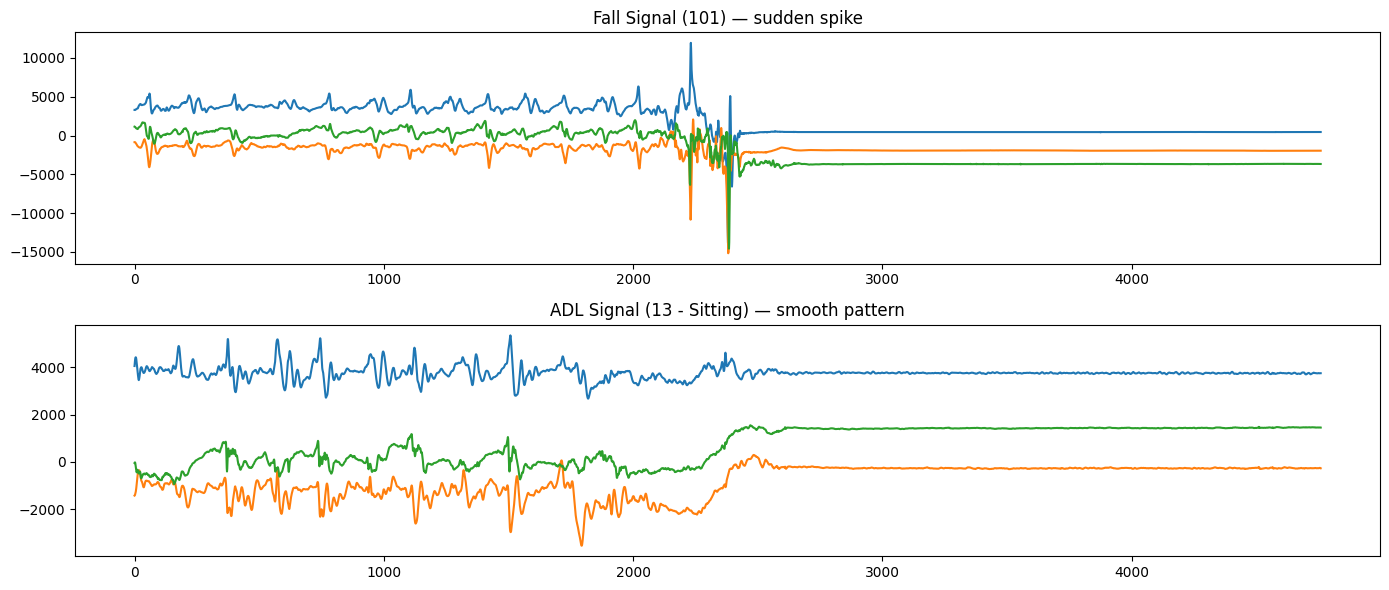

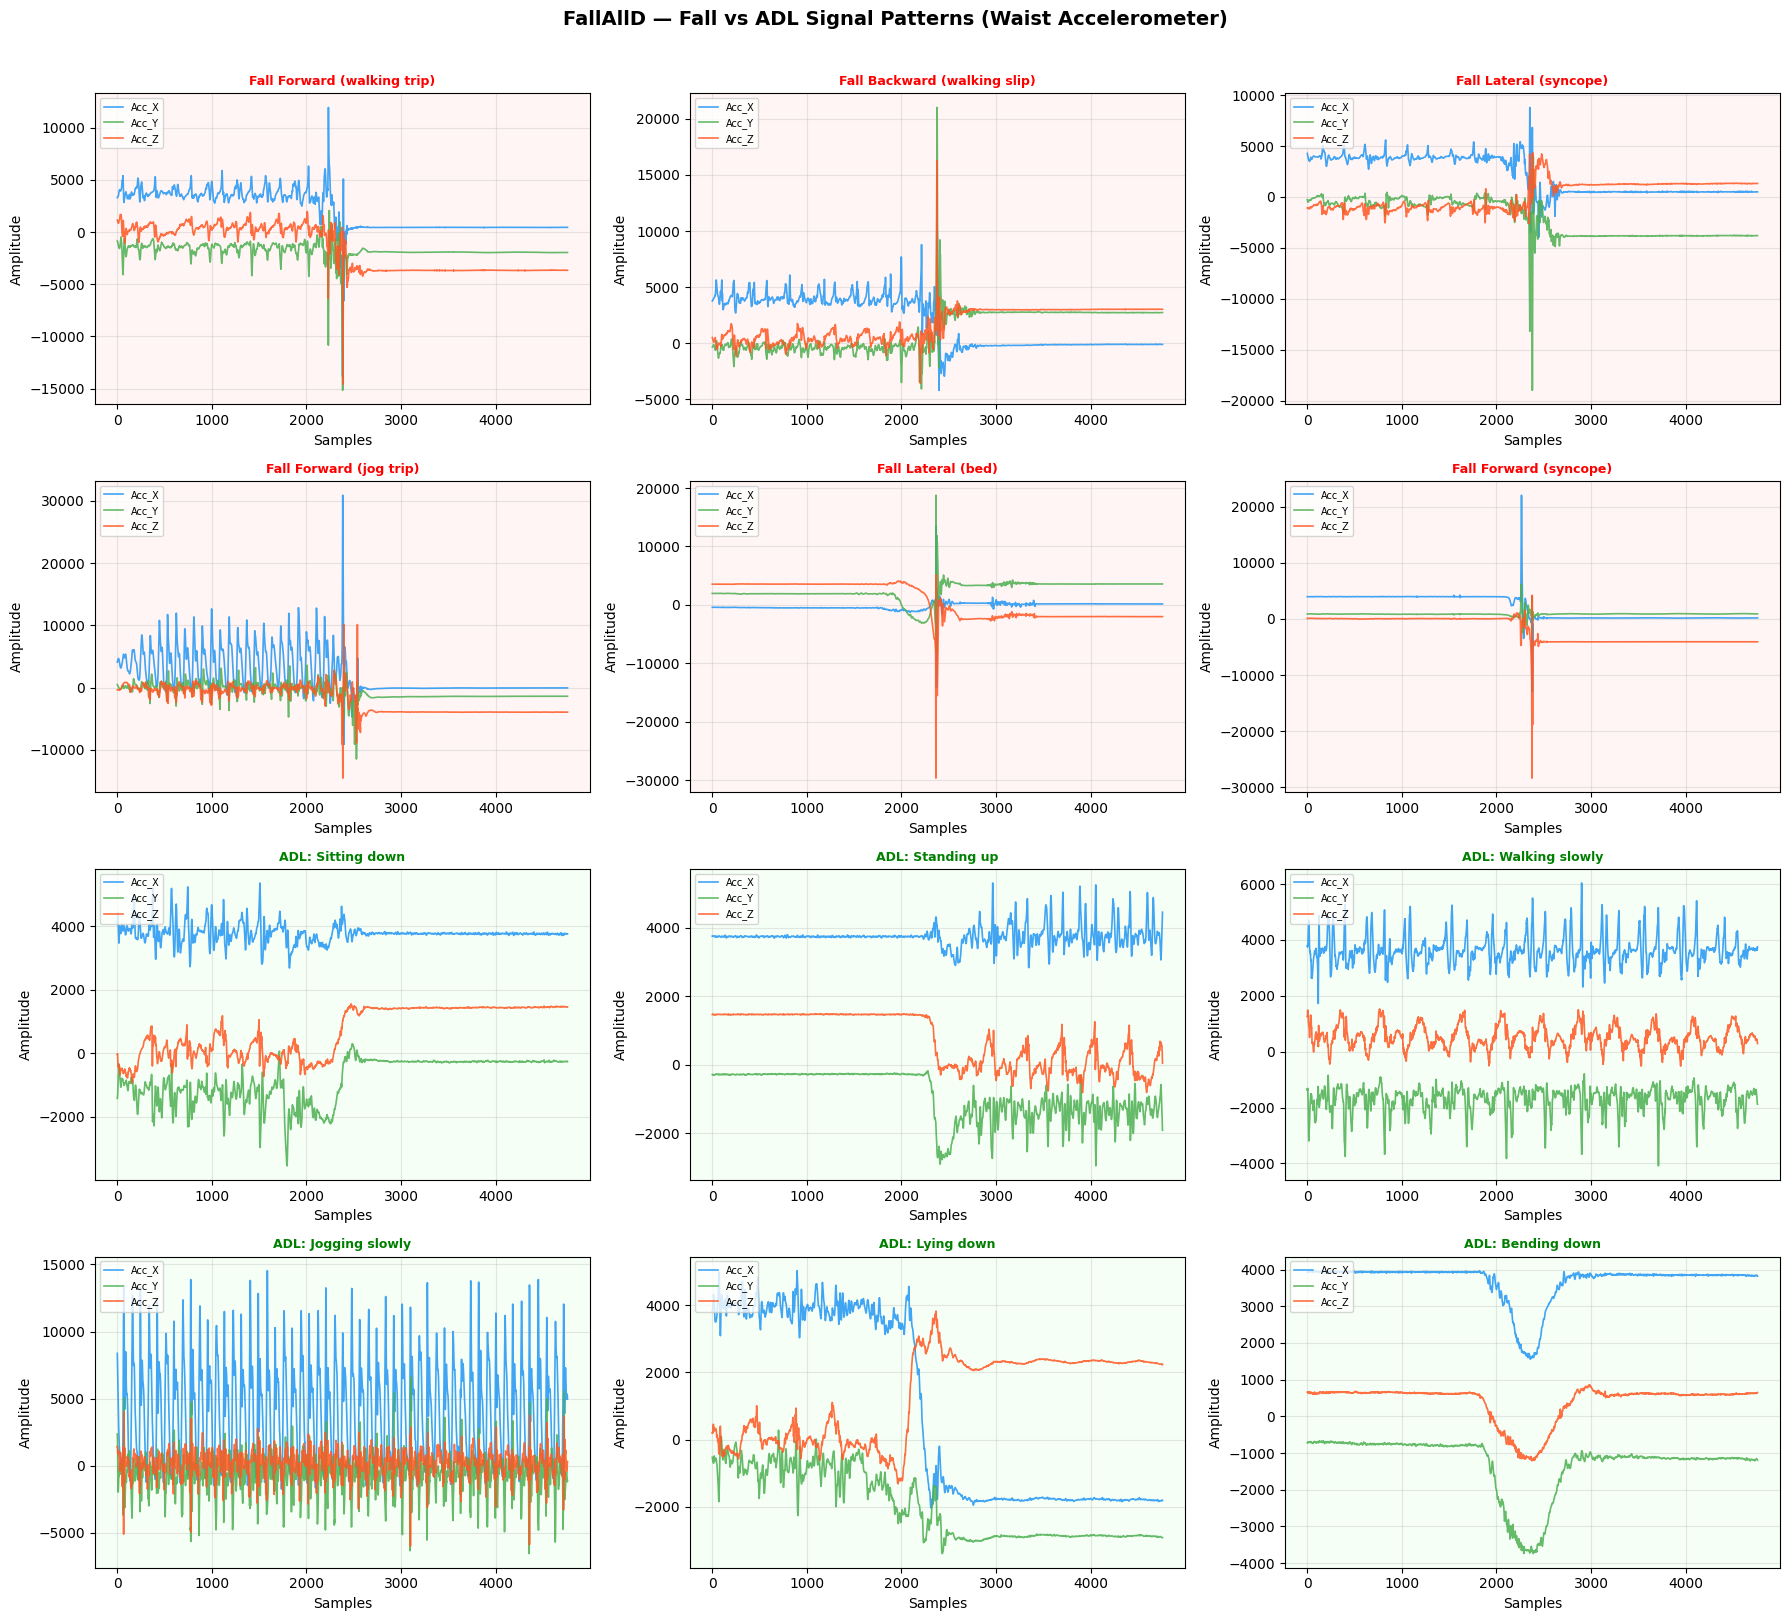

In [8]:
import numpy as np
import pandas as pd
import pickle, os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

FALLALLD_PATH = '/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl'

print("Loading FallAllD...")
with open(FALLALLD_PATH, 'rb') as f:
    df_fa = pickle.load(f)

waist_df = df_fa[df_fa['Device'] == 'Waist']

fall_ids = [101, 107, 113, 121, 127, 132]
adl_ids  = [13, 14, 20, 24, 16, 28]

activity_names = {
    101: 'Fall Forward (walking trip)',
    107: 'Fall Backward (walking slip)',
    113: 'Fall Lateral (syncope)',
    121: 'Fall Forward (jog trip)',
    127: 'Fall Lateral (bed)',
    132: 'Fall Forward (syncope)',
    13:  'ADL: Sitting down',
    14:  'ADL: Standing up',
    20:  'ADL: Walking slowly',
    24:  'ADL: Jogging slowly',
    16:  'ADL: Lying down',
    28:  'ADL: Bending down',
}

colors = ['#2196F3', '#4CAF50', '#FF5722']
labels = ['Acc_X', 'Acc_Y', 'Acc_Z']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('FallAllD — Fall vs ADL Signal Patterns (Waist Accelerometer)',
             fontsize=14, fontweight='bold', y=1.01)

for i, act_id in enumerate(fall_ids):
    row, col = i // 3, i % 3
    subset = waist_df[waist_df['ActivityID'] == act_id]
    if len(subset) == 0: continue
    acc = np.array(subset['Acc'].iloc[0])
    for j, (c, l) in enumerate(zip(colors, labels)):
        axes[row][col].plot(acc[:, j], color=c, label=l, linewidth=1.2, alpha=0.85)
    axes[row][col].set_title(activity_names[act_id], fontsize=9, fontweight='bold', color='red')
    axes[row][col].set_ylabel('Amplitude')
    axes[row][col].set_xlabel('Samples')
    axes[row][col].legend(fontsize=7, loc='upper left')
    axes[row][col].grid(alpha=0.3)
    axes[row][col].set_facecolor('#FFF5F5')

for i, act_id in enumerate(adl_ids):
    row, col = (i // 3) + 2, i % 3
    subset = waist_df[waist_df['ActivityID'] == act_id]
    if len(subset) == 0: continue
    acc = np.array(subset['Acc'].iloc[0])
    for j, (c, l) in enumerate(zip(colors, labels)):
        axes[row][col].plot(acc[:, j], color=c, label=l, linewidth=1.2, alpha=0.85)
    axes[row][col].set_title(activity_names[act_id], fontsize=9, fontweight='bold', color='green')
    axes[row][col].set_ylabel('Amplitude')
    axes[row][col].set_xlabel('Samples')
    axes[row][col].legend(fontsize=7, loc='upper left')
    axes[row][col].grid(alpha=0.3)
    axes[row][col].set_facecolor('#F5FFF5')

plt.tight_layout()
plt.savefig('/kaggle/working/fallalld_signal_visualization.png',
            dpi=150, bbox_inches='tight')
plt.show()  


## 7. Feature Importance / Ablation Analysis

Zero out each input channel (Acc_X/Y/Z, Gyr_X/Y/Z) one at a time and measure the drop in AUC to identify the most critical sensor channels.

Loading FallAllD...
Total: 28768 | Falls=7456 | ADL=21312
Loading model...
Baseline AUC: 0.9747
  Acc_X: AUC drop = 0.2124 (AUC=0.7623)
  Acc_Y: AUC drop = 0.0258 (AUC=0.9488)
  Acc_Z: AUC drop = 0.0503 (AUC=0.9243)
  Gyr_X: AUC drop = 0.0184 (AUC=0.9562)
  Gyr_Y: AUC drop = 0.2405 (AUC=0.7342)
  Gyr_Z: AUC drop = 0.0433 (AUC=0.9314)


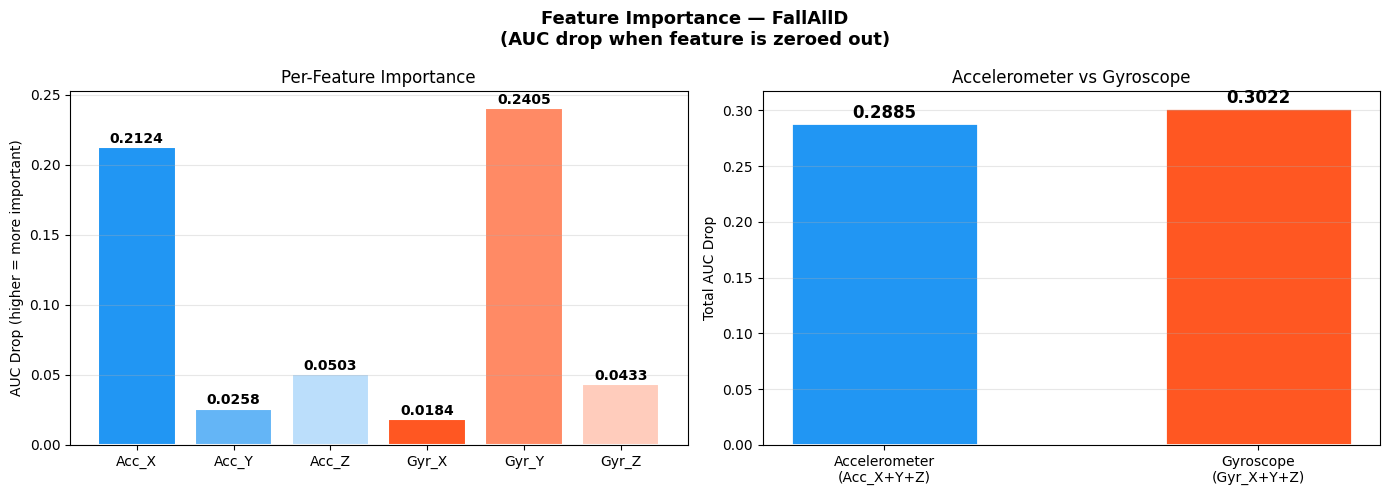

Done!


In [9]:
import numpy as np
import pandas as pd
import pickle, os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

FALLALLD_PATH  = '/kaggle/input/datasets/sankalpsinghvishen/derived-fallalld-dataset/FallAllD.pkl'
FALLALLD_MODEL = '/kaggle/input/models/mandavisingh/fallaiid-final/keras/default/1/fallalld_correct_final.keras'
OUTPUT_DIR     = '/kaggle/working/'

TARGET_HZ   = 50
WINDOW_SIZE = 250
STEP_SIZE   = 50
N_FEATURES  = 6

def resample_signal(signal, orig_hz, target_hz):
    orig_len   = len(signal)
    target_len = int(orig_len * target_hz / orig_hz)
    if target_len < 2: return signal
    orig_t   = np.linspace(0, 1, orig_len)
    target_t = np.linspace(0, 1, target_len)
    if signal.ndim == 1:
        return np.interp(target_t, orig_t, signal)
    return np.column_stack([
        np.interp(target_t, orig_t, signal[:, i])
        for i in range(signal.shape[1])
    ])

def sliding_window(signal, window_size, step_size):
    windows, T, start = [], signal.shape[0], 0
    while start + window_size <= T:
        windows.append(signal[start:start + window_size])
        start += step_size
    return windows

# Load data
print("Loading FallAllD...")
with open(FALLALLD_PATH, 'rb') as f:
    df_fa = pickle.load(f)

X_all, y_all = [], []
for subj in sorted(df_fa['SubjectID'].unique()):
    subj_df = df_fa[(df_fa['SubjectID'] == subj) & (df_fa['Device'] == 'Waist')]
    for (act_id, trial_no), grp in subj_df.groupby(['ActivityID','TrialNo']):
        label = 1 if act_id >= 101 else 0
        for _, row in grp.iterrows():
            acc = np.array(row['Acc'], dtype=np.float32)
            gyr = np.array(row['Gyr'], dtype=np.float32)
            acc_rs = resample_signal(acc, 238, TARGET_HZ)
            gyr_rs = resample_signal(gyr, 238, TARGET_HZ)
            min_len = min(acc_rs.shape[0], gyr_rs.shape[0])
            combined = np.concatenate(
                [acc_rs[:min_len], gyr_rs[:min_len]], axis=1
            ).astype(np.float32)
            if combined.shape[0] < WINDOW_SIZE: continue
            for w in sliding_window(combined, WINDOW_SIZE, STEP_SIZE):
                if w.shape == (WINDOW_SIZE, N_FEATURES):
                    X_all.append(w); y_all.append(label)

X_fa = np.array(X_all, dtype=np.float32)
y_fa = np.array(y_all, dtype=np.int32)
print(f"Total: {len(y_fa)} | Falls={y_fa.sum()} | ADL={len(y_fa)-y_fa.sum()}")

# Scale
scaler = StandardScaler()
n, T, F = X_fa.shape
X_sc = scaler.fit_transform(X_fa.reshape(-1,F)).reshape(n,T,F)

# Load model
print("Loading model...")
model = tf.keras.models.load_model(FALLALLD_MODEL, compile=False)

# Baseline AUC
base_pred = model.predict(X_sc, batch_size=256, verbose=0).flatten()
base_auc  = roc_auc_score(y_fa, base_pred)
print(f"Baseline AUC: {base_auc:.4f}")

# Feature importance — zero out each feature
feature_names = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z']
feat_importance = []

for feat_idx in range(N_FEATURES):
    X_zeroed = X_sc.copy()
    X_zeroed[:, :, feat_idx] = 0
    pred = model.predict(X_zeroed, batch_size=256, verbose=0).flatten()
    auc  = roc_auc_score(y_fa, pred)
    drop = base_auc - auc
    feat_importance.append(drop)
    print(f"  {feature_names[feat_idx]}: AUC drop = {drop:.4f} (AUC={auc:.4f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance — FallAllD\n(AUC drop when feature is zeroed out)',
             fontsize=13, fontweight='bold')

colors_feat = ['#2196F3','#64B5F6','#BBDEFB',
               '#FF5722','#FF8A65','#FFCCBC']
bars = axes[0].bar(feature_names, feat_importance,
                   color=colors_feat, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('AUC Drop (higher = more important)')
axes[0].set_title('Per-Feature Importance')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, feat_importance):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.001,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# Acc vs Gyr
acc_imp = sum(feat_importance[:3])
gyr_imp = sum(feat_importance[3:])
axes[1].bar(['Accelerometer\n(Acc_X+Y+Z)', 'Gyroscope\n(Gyr_X+Y+Z)'],
            [acc_imp, gyr_imp],
            color=['#2196F3','#FF5722'],
            edgecolor='white', linewidth=2, width=0.5)
axes[1].set_ylabel('Total AUC Drop')
axes[1].set_title('Accelerometer vs Gyroscope')
axes[1].grid(axis='y', alpha=0.3)
for i, val in enumerate([acc_imp, gyr_imp]):
    axes[1].text(i, val+0.001, f'{val:.4f}',
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'analysis2_feature_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Done!")